# Advanced Data Mining for Data-Driven Insights and Predictive Modeling

## Project Deliverable 1: Data Collection, Cleaning, and Exploration

**Course:** 2026 Summer - Advanced Big Data and Data Mining  
**Course Number:** MSCS-634-M20  
**Date:** July 24–26, 2026  
**Dataset:** Credit Card Fraud Detection  
**Dataset Source:** [Credit Card Fraud Detection on Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

**Group Members:**  
Ashish Mahajan  
Murali Krishna Vattikunta  
Sreesh Sattiyamourthy  
Sreeharsha Varma Tinnanuri

### Project Purpose

This project studies anonymized European credit-card transactions to develop data-driven insights and predictive modeling workflows for fraud analysis. Deliverable 1 establishes a reproducible, leakage-aware data foundation through inspection, exact-duplicate cleaning, extreme-value diagnostics, class-imbalance analysis, feature engineering, and exploratory visualization.

### Objectives

- Inspect and clean the approved dataset without fabricating or discarding potential fraud signals.
- Quantify class imbalance and create focused, reproducible EDA outputs.
- Use the findings to define leakage-safe requirements for later modeling.

### Dataset and Ethical Note

Only the approved Kaggle dataset is used. Anonymized PCA features limit direct interpretation, while false positives and false negatives can affect customers and financial institutions.

### Notebook Roadmap

1. Load and validate the approved dataset.
2. Inspect structure and define the data dictionary.
3. Audit missing values and exact duplicates.
4. Review noise, extremes, and class imbalance.
5. Engineer exploratory features.
6. Create and interpret focused visualizations.
7. Save reproducible artifacts and connect findings to future modeling.

## 1. Imports and Reproducible Settings

**Objective:** Load the libraries used in this deliverable, create its output directories, and establish consistent display and plotting behavior.

In [1]:
import shutil
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
PCA_COLUMNS = [f"V{number}" for number in range(1, 29)]
REQUIRED_COLUMNS = ["Time", *PCA_COLUMNS, "Amount", "Class"]

Path("data").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)
Path("images/deliverable_1").mkdir(parents=True, exist_ok=True)

def load_credit_card_data():
    dataset_path = next(
        (path for path in (Path("data/creditcard.csv"), Path("creditcard.csv")) if path.is_file()),
        None,
    )
    if dataset_path is None:
        raise FileNotFoundError("Place creditcard.csv in data/ or download it with KaggleHub.")
    dataframe = pd.read_csv(dataset_path)
    if dataframe.columns.tolist() != REQUIRED_COLUMNS:
        raise ValueError("Dataset columns do not match the approved credit-card dataset.")
    return dataframe, dataset_path

def clean_credit_card_data(dataframe):
    if dataframe["Class"].isna().any() or not set(dataframe["Class"].unique()).issubset({0, 1}):
        raise ValueError("Class must contain only 0 and 1 with no missing values.")
    if (dataframe[["Time", "Amount"]] < 0).any().any():
        raise ValueError("Time and Amount must be nonnegative.")
    return dataframe.drop_duplicates().reset_index(drop=True)

def create_base_features(dataframe):
    featured = dataframe.copy()
    featured["Hour"] = (featured["Time"] / 3600) % 24
    featured["DayIndex"] = np.floor(featured["Time"] / 86400).astype(int)
    featured["LogAmount"] = np.log1p(featured["Amount"])
    return featured

def create_cleaning_summary(original, cleaned):
    original_counts = original["Class"].value_counts().reindex([0, 1], fill_value=0)
    cleaned_counts = cleaned["Class"].value_counts().reindex([0, 1], fill_value=0)
    rows = [
        ("Original rows", len(original)),
        ("Exact duplicate rows", int(original.duplicated().sum())),
        ("Rows after duplicate removal", len(cleaned)),
        ("Original legitimate rows", int(original_counts.loc[0])),
        ("Original fraud rows", int(original_counts.loc[1])),
        ("Cleaned legitimate rows", int(cleaned_counts.loc[0])),
        ("Cleaned fraud rows", int(cleaned_counts.loc[1])),
        ("Legitimate duplicates removed", int(original_counts.loc[0] - cleaned_counts.loc[0])),
        ("Fraud duplicates removed", int(original_counts.loc[1] - cleaned_counts.loc[1])),
    ]
    return pd.DataFrame(rows, columns=["Measure", "Value"])

def save_figure(path):
    destination = Path(path)
    destination.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(destination, dpi=180, bbox_inches="tight")

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

## 2. Dataset Selection and Loading

**Objective:** Load only the approved Kaggle credit-card dataset using relative paths. The loader checks `data/creditcard.csv` first and `creditcard.csv` second, validates the expected schema, and raises clear setup guidance if neither file exists.

The dataset exceeds the project minimum of 500 records and 8-10 attributes. Its numerical transaction features support later regression, classification, clustering, and discretized pattern-mining tasks. The extreme target imbalance makes it a realistic fraud-modeling problem, while anonymized PCA features reduce direct domain interpretation.

### Local Dataset Setup

The notebook first checks for `data/creditcard.csv` and `creditcard.csv`. If neither file exists, KaggleHub downloads `mlg-ulb/creditcardfraud`, and the notebook copies `creditcard.csv` into the ignored `data/` directory.

The raw CSV and Kaggle credentials must not be committed. No substitute dataset is used.

In [2]:
# Prefer the ignored local file; use KaggleHub only when the approved CSV is absent.
try:
    raw_df, dataset_path = load_credit_card_data()
except FileNotFoundError:
    path = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud"))
    print("Path to dataset files:", path)
    downloaded_files = list(path.rglob("creditcard.csv"))
    if len(downloaded_files) != 1:
        raise FileNotFoundError(
            f"Expected one creditcard.csv in the KaggleHub download, found {len(downloaded_files)}."
        )
    local_dataset_path = Path("data/creditcard.csv")
    local_dataset_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(downloaded_files[0], local_dataset_path)
    raw_df, dataset_path = load_credit_card_data()
print(f"Loaded dataset from: {dataset_path}")
print(f"Original shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
display(raw_df.head())

Loaded dataset from: data/creditcard.csv
Original shape: 284,807 rows x 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


**Interpretation and next step:** Successful loading confirms that the approved local dataset and expected schema are present. The next section examines data types, numerical ranges, and the target distribution before any cleaning occurs.

## 3. Structural Inspection and Data Dictionary

**Objective:** Inspect the original dataset before transformation so later cleaning decisions are auditable. Full-precision values remain in the DataFrame; formatting is applied only to displayed copies.

In [3]:
# Inspect the unmodified frame so all later cleaning decisions have a baseline.
print("Shape:", raw_df.shape)
print("Columns:", raw_df.columns.tolist())

print("\nData types:")
display(raw_df.dtypes.rename("Data Type").to_frame())

print("\nDataFrame information:")
raw_df.info()

print("\nDescriptive statistics:")
display(raw_df.describe().T)

print("\nUnique target values:", sorted(raw_df["Class"].dropna().unique().tolist()))
original_class_counts = raw_df["Class"].value_counts().reindex([0, 1], fill_value=0)
original_class_percentages = raw_df["Class"].value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100
original_class_summary = pd.DataFrame({
    "Class Label": ["Legitimate", "Fraud"],
    "Count": original_class_counts.values.astype(int),
    "Percentage": original_class_percentages.values,
}, index=[0, 1])
display(original_class_summary.style.format({"Count": "{:,.0f}", "Percentage": "{:.2f}%"}))

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:


,Data Type
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64



DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950



Unique target values: [0, 1]


,Class Label,Count,Percentage
0,Legitimate,"284,315",99.83%
1,Fraud,492,0.17%


In [4]:
# Build all 31 dictionary entries programmatically to avoid omitting PCA columns.
data_dictionary_rows = [
    {
        "Column": "Time",
        "Type": str(raw_df["Time"].dtype),
        "Meaning": "Seconds elapsed between each transaction and the first transaction.",
    },
    *[
        {
            "Column": column,
            "Type": str(raw_df[column].dtype),
            "Meaning": f"Anonymized PCA-transformed numerical feature {column}.",
        }
        for column in PCA_COLUMNS
    ],
    {
        "Column": "Amount",
        "Type": str(raw_df["Amount"].dtype),
        "Meaning": "Transaction amount in the dataset currency.",
    },
    {
        "Column": "Class",
        "Type": str(raw_df["Class"].dtype),
        "Meaning": "Target: 0 is legitimate and 1 is fraudulent.",
    },
]
data_dictionary = pd.DataFrame(data_dictionary_rows)
display(data_dictionary)

dataset_profile = pd.DataFrame({
    "Measure": [
        "Original rows",
        "Original columns",
        "Missing cells",
        "Exact duplicate rows",
        "Unique target values",
        "Legitimate rows",
        "Fraud rows",
        "Minimum Time",
        "Maximum Time",
        "Minimum Amount",
        "Maximum Amount",
    ],
    "Value": pd.Series([
        len(raw_df),
        raw_df.shape[1],
        int(raw_df.isna().sum().sum()),
        int(raw_df.duplicated().sum()),
        int(raw_df["Class"].nunique(dropna=True)),
        int(original_class_counts.loc[0]),
        int(original_class_counts.loc[1]),
        float(raw_df["Time"].min()),
        float(raw_df["Time"].max()),
        raw_df["Amount"].min(),
        raw_df["Amount"].max(),
    ], dtype="object"),
})
# Export raw values; display formatting never changes saved calculation precision.
dataset_profile.to_csv("results/deliverable_1_dataset_profile.csv", index=False)
display(dataset_profile)

,Column,Type,Meaning
0,Time,float64,Seconds elapsed between each transaction and t...
1,V1,float64,Anonymized PCA-transformed numerical feature V1.
2,V2,float64,Anonymized PCA-transformed numerical feature V2.
3,V3,float64,Anonymized PCA-transformed numerical feature V3.
4,V4,float64,Anonymized PCA-transformed numerical feature V4.
5,V5,float64,Anonymized PCA-transformed numerical feature V5.
6,V6,float64,Anonymized PCA-transformed numerical feature V6.
7,V7,float64,Anonymized PCA-transformed numerical feature V7.
8,V8,float64,Anonymized PCA-transformed numerical feature V8.
9,V9,float64,Anonymized PCA-transformed numerical feature V9.


,Measure,Value
0,Original rows,284807
1,Original columns,31
2,Missing cells,0
3,Exact duplicate rows,1081
4,Unique target values,2
5,Legitimate rows,284315
6,Fraud rows,492
7,Minimum Time,0.0000
8,Maximum Time,"172,792.0000"
9,Minimum Amount,0.0000


**Interpretation and next step:** `Time`, `V1` through `V28`, and `Amount` are numerical predictors, while `Class` is the binary target. The PCA transformation improves privacy but prevents direct interpretation of the original financial variables. The next audit determines whether missing values require treatment.

## 4. Missing-Value Audit

**Objective:** Report missing values for every column. Imputation is used only when genuine missingness exists; artificial missing values are not introduced for demonstration.

In [5]:
# Report genuine missingness without fabricating records for an imputation example.
missing_summary = raw_df.isna().sum().rename("Missing Values").to_frame()
missing_summary["Missing Percentage"] = missing_summary["Missing Values"] / len(raw_df) * 100
display(missing_summary.style.format({
    "Missing Values": "{:,.0f}",
    "Missing Percentage": "{:.2f}%",
}))
print(f"Total missing cells: {int(missing_summary['Missing Values'].sum()):,}")

,Missing Values,Missing Percentage
Time,0,0.00%
V1,0,0.00%
V2,0,0.00%
V3,0,0.00%
V4,0,0.00%
V5,0,0.00%
V6,0,0.00%
V7,0,0.00%
V8,0,0.00%
V9,0,0.00%


Total missing cells: 0


**Interpretation and next step:** If the executed audit reports zero missing values, imputation is unnecessary and could alter valid observations. If missingness appears, execution should stop for investigation rather than silently applying an unplanned strategy. The next section measures and removes only exact duplicate records.

## 5. Exact-Duplicate Cleaning

**Objective:** Remove exact duplicate transaction rows so repeated copies cannot inflate later patterns or evaluation results. Class counts are compared before and after deduplication, including the number of duplicated fraud records removed.

In [6]:
# Capture class counts before cleaning so rare fraud removals remain visible.
original_row_count = len(raw_df)
exact_duplicate_count = int(raw_df.duplicated().sum())
class_counts_before = raw_df["Class"].value_counts().reindex([0, 1], fill_value=0)

# The cleaning helper validates core fields and removes only exact duplicates.
clean_df = clean_credit_card_data(raw_df)
class_counts_after = clean_df["Class"].value_counts().reindex([0, 1], fill_value=0)

cleaning_summary = create_cleaning_summary(raw_df, clean_df)
cleaning_summary.to_csv("results/deliverable_1_cleaning_summary.csv", index=False)

class_comparison = pd.DataFrame({
    "Class Label": ["Legitimate", "Fraud"],
    "Before Deduplication": class_counts_before.values.astype(int),
    "After Deduplication": class_counts_after.values.astype(int),
    "Duplicates Removed": (class_counts_before - class_counts_after).values.astype(int),
}, index=[0, 1])

print(f"Original rows: {original_row_count:,}")
print(f"Exact duplicate rows: {exact_duplicate_count:,}")
print(f"Rows after duplicate removal: {len(clean_df):,}")
display(class_comparison.style.format({
    "Before Deduplication": "{:,.0f}",
    "After Deduplication": "{:,.0f}",
    "Duplicates Removed": "{:,.0f}",
}))
display(cleaning_summary.style.format({"Value": "{:,.0f}"}))

Original rows: 284,807
Exact duplicate rows: 1,081
Rows after duplicate removal: 283,726


,Class Label,Before Deduplication,After Deduplication,Duplicates Removed
0,Legitimate,"284,315","283,253","1,062"
1,Fraud,492,473,19


,Measure,Value
0,Original rows,"284,807"
1,Exact duplicate rows,"1,081"
2,Rows after duplicate removal,"283,726"
3,Original legitimate rows,"284,315"
4,Original fraud rows,492
5,Cleaned legitimate rows,"283,253"
6,Cleaned fraud rows,473
7,Legitimate duplicates removed,"1,062"
8,Fraud duplicates removed,19


**Interpretation and next step:** Only exact duplicates are removed. Similar-looking transactions are retained because they may be independent legitimate purchases or meaningful fraud events. The class comparison shows whether deduplication disproportionately affected fraud records. The next section distinguishes invalid data from statistically extreme but potentially valid transactions.

## 6. Noise and Extreme-Value Analysis

**Objective:** Review transaction amount tails, selected PCA ranges, and the largest transactions without automatically treating extremes as errors. Fraud itself may appear anomalous, so blind IQR deletion could destroy target signal.

In [7]:
# Use target correlation only to focus EDA panels; later model selection must use training data only.
pca_class_correlations = clean_df[PCA_COLUMNS + ["Class"]].corr()["Class"].drop("Class")
selected_pca_features = (
    pca_class_correlations.abs()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

# Percentiles diagnose the heavy tail without treating valid extremes as errors.
amount_extremes = pd.DataFrame({
    "Statistic": ["Maximum", "95th percentile", "99th percentile", "99.9th percentile"],
    "Amount": [
        clean_df["Amount"].max(),
        clean_df["Amount"].quantile(0.95),
        clean_df["Amount"].quantile(0.99),
        clean_df["Amount"].quantile(0.999),
    ],
})
selected_pca_ranges = clean_df[selected_pca_features].agg(["min", "max"]).T
selected_pca_ranges["Range"] = selected_pca_ranges["max"] - selected_pca_ranges["min"]
top_amount_transactions = clean_df.nlargest(
    10, "Amount"
)[["Time", *selected_pca_features, "Amount", "Class"]]

print("Amount extreme-value summary:")
display(amount_extremes.style.format({"Amount": "${:,.2f}"}))
print("Selected PCA feature ranges:")
display(selected_pca_ranges)
print("Top transactions by Amount:")
display(top_amount_transactions.style.format({"Amount": "${:,.2f}"}))

Amount extreme-value summary:


,Statistic,Amount
0,Maximum,"$25,691.16"
1,95th percentile,$365.34
2,99th percentile,"$1,018.97"
3,99.9th percentile,"$3,004.75"


Selected PCA feature ranges:


,min,max,Range
V17,-25.1628,9.2535,34.4163
V14,-19.2143,10.5268,29.7411
V12,-18.6837,7.8484,26.5321
V10,-24.5883,23.7451,48.3334
V16,-14.1299,17.3151,31.4450
V3,-48.3256,9.3826,57.7081


Top transactions by Amount:


,Time,V17,V14,V12,V10,V16,V3,Amount,Class
273745,166198.000000,-7.173805,-6.795942,-9.189418,-12.005487,17.315112,-48.325589,"$25,691.16",0
58220,48401.000000,0.902964,4.082503,1.879982,-8.423404,0.773133,-20.645794,"$19,656.53",0
150705,95286.000000,0.530779,5.989210,-2.281866,-8.908182,3.032874,-21.340854,"$18,910.00",0
46641,42951.000000,1.413407,2.354131,0.902675,-5.533256,2.068475,-13.320825,"$12,910.93",0
53784,46253.000000,-0.613875,2.788521,0.832726,-5.545590,2.721505,-12.122469,"$11,898.09",0
168820,119713.000000,0.297532,2.969936,1.361297,-5.341249,1.134212,-14.060281,"$11,789.84",0
283168,172273.000000,-0.402142,0.537895,-4.499851,-7.776435,2.326099,-16.233798,"$10,199.44",0
227081,145283.000000,1.174609,4.109779,3.108922,-2.166867,0.554018,-8.303035,"$10,000.00",0
74408,55709.000000,-1.745472,-3.041540,-1.619834,-2.856014,5.000096,-12.523381,"$8,790.26",0
244563,152763.000000,0.341256,2.677857,-0.204348,-2.973570,1.634390,-12.714462,"$8,787.00",0


**Interpretation and next step:** Statistical extremes are not automatically invalid. Large amounts may be legitimate, and unusual PCA patterns may contain the fraud signal the project is intended to study. No statistical extreme is deleted in this deliverable. The next section quantifies the target imbalance that will shape all later model evaluation.

## 7. Class Imbalance

**Objective:** Calculate legitimate and fraud counts, percentages, and the imbalance ratio after duplicate removal. A logarithmic count axis keeps the rare fraud class visible without concealing the scale difference.

,Class Label,Count,Percentage
0,Legitimate,"283,253",99.83%
1,Fraud,473,0.17%


Legitimate-to-fraud imbalance ratio: 598.84:1


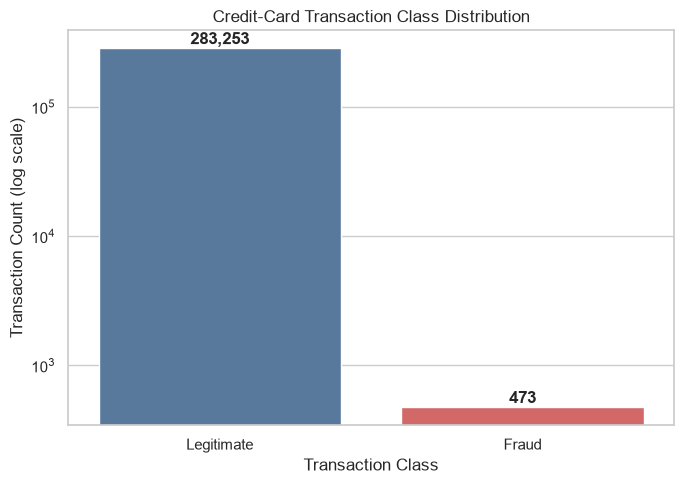

In [8]:
# Reindex both classes so an unexpected empty class cannot silently disappear.
cleaned_class_counts = clean_df["Class"].value_counts().reindex([0, 1], fill_value=0)
cleaned_class_percentages = cleaned_class_counts / len(clean_df) * 100
imbalance_ratio = cleaned_class_counts.loc[0] / cleaned_class_counts.loc[1]

class_summary = pd.DataFrame({
    "Class Label": ["Legitimate", "Fraud"],
    "Count": cleaned_class_counts.values.astype(int),
    "Percentage": cleaned_class_percentages.values,
}, index=[0, 1])
display(class_summary.style.format({"Count": "{:,.0f}", "Percentage": "{:.2f}%"}))
print(f"Legitimate-to-fraud imbalance ratio: {imbalance_ratio:,.2f}:1")

plt.figure(figsize=(7, 5))
axis = sns.barplot(
    x=class_summary["Class Label"],
    y=class_summary["Count"],
    hue=class_summary["Class Label"],
    palette=["#4C78A8", "#E45756"],
    legend=False,
)
# A log axis keeps the rare fraud bar visible while preserving the true counts.
axis.set_yscale("log")
axis.set_title("Credit-Card Transaction Class Distribution")
axis.set_xlabel("Transaction Class")
axis.set_ylabel("Transaction Count (log scale)")
for index, value in enumerate(class_summary["Count"]):
    axis.text(index, value * 1.08, f"{value:,.0f}", ha="center", fontweight="bold")
save_figure("images/deliverable_1/01_class_distribution.png")
plt.show()

**Interpretation and next step:** The rare fraud class means a model could achieve high accuracy by predicting nearly every transaction as legitimate. Later classification work must prioritize precision, recall, F1, ROC-AUC, and especially PR-AUC, while preserving class proportions through stratified splitting and cross-validation. The next section adds exploratory features without overwriting the original variables.

## 8. Feature Engineering for EDA

**Objective:** Add `Hour`, `DayIndex`, and `LogAmount` as non-destructive exploratory features. `LogAmount` reduces visual compression caused by the strongly right-skewed raw amount, while `Hour` and `DayIndex` expose cyclical and sequential timing patterns.

In [9]:
# Add exploratory columns on a copy so original Time and Amount remain available.
eda_df = create_base_features(clean_df)
engineered_preview = eda_df[["Time", "Hour", "DayIndex", "Amount", "LogAmount", "Class"]].head()
display(engineered_preview)

feature_check = pd.DataFrame({
    "Feature": ["Hour", "DayIndex", "LogAmount"],
    "Minimum": [eda_df["Hour"].min(), eda_df["DayIndex"].min(), eda_df["LogAmount"].min()],
    "Maximum": [eda_df["Hour"].max(), eda_df["DayIndex"].max(), eda_df["LogAmount"].max()],
})
display(feature_check)

,Time,Hour,DayIndex,Amount,LogAmount,Class
0,0.0000,0.0000,0,149.6200,5.0148,0
1,0.0000,0.0000,0,2.6900,1.3056,0
2,1.0000,0.0003,0,378.6600,5.9393,0
3,1.0000,0.0003,0,123.5000,4.8243,0
4,2.0000,0.0006,0,69.9900,4.2625,0


,Feature,Minimum,Maximum
0,Hour,0.0000,23.9994
1,DayIndex,0.0000,1.0000
2,LogAmount,0.0000,10.1539


**Interpretation and next step:** The original `Time` and `Amount` columns remain unchanged. These engineered views improve EDA and establish candidate transformations for later leakage-safe pipelines. The following visualizations examine amount, time, PCA distributions, and target correlation.

## 9. Focused Exploratory Visualizations

**Objective:** Produce readable, automatically saved figures that reveal skew, class differences, temporal behavior, focused PCA patterns, and association with the target. Dense scatter plots use reproducible legitimate-class sampling plus all fraud records.

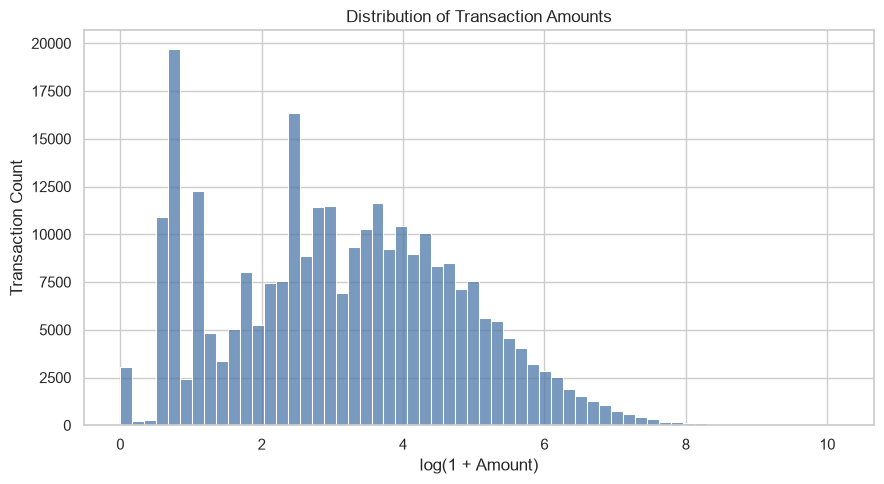

In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(eda_df["LogAmount"], bins=60, color="#4C78A8")
plt.title("Distribution of Transaction Amounts")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Transaction Count")
save_figure("images/deliverable_1/02_amount_distribution.png")
plt.show()

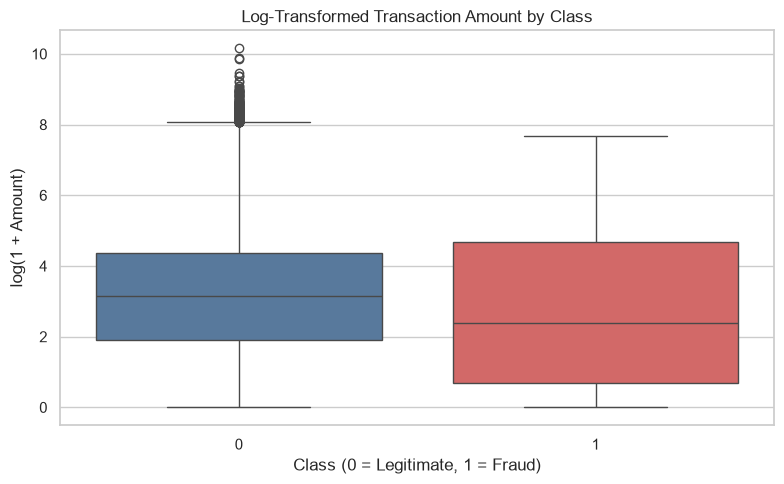

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=eda_df,
    x="Class",
    y="LogAmount",
    hue="Class",
    palette=["#4C78A8", "#E45756"],
    legend=False,
)
plt.title("Log-Transformed Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("log(1 + Amount)")
save_figure("images/deliverable_1/03_log_amount_by_class.png")
plt.show()

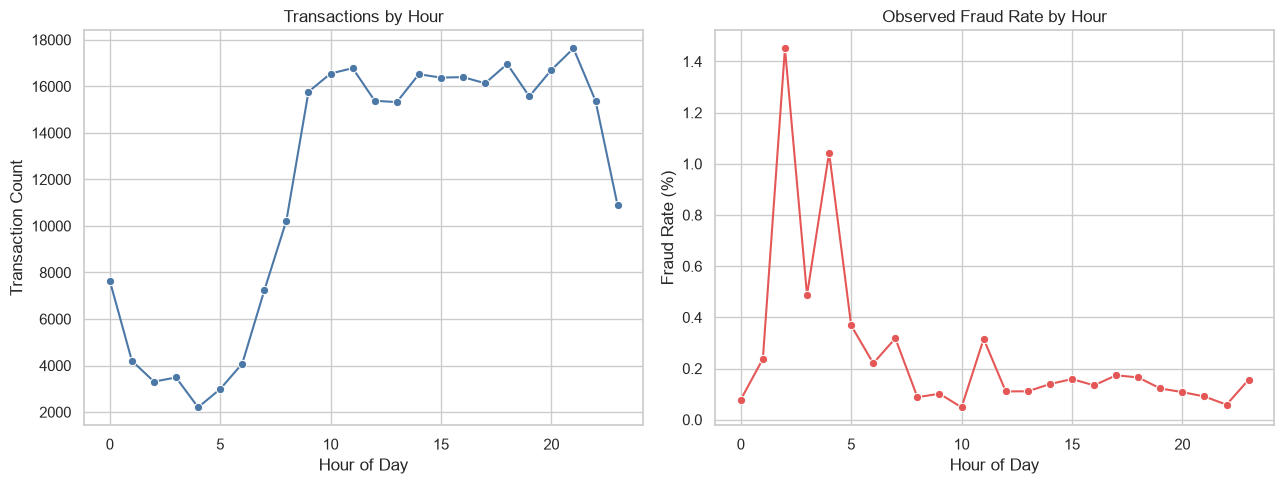

,HourBin,Transactions,FraudTransactions,Fraud Rate
0,0,"7,647",6,0.0785%
1,1,"4,208",10,0.2376%
2,2,"3,308",48,1.4510%
3,3,"3,487",17,0.4875%
4,4,"2,204",23,1.0436%
5,5,"2,988",11,0.3681%
6,6,"4,082",9,0.2205%
7,7,"7,233",23,0.3180%
8,8,"10,232",9,0.0880%
9,9,"15,767",16,0.1015%


In [12]:
hourly_summary = (
    eda_df.assign(HourBin=np.floor(eda_df["Hour"]).astype(int))
    .groupby("HourBin")
    .agg(
        Transactions=("Class", "size"),
        FraudTransactions=("Class", "sum"),
    )
    .reset_index()
)
hourly_summary["Fraud Rate"] = hourly_summary["FraudTransactions"] / hourly_summary["Transactions"] * 100

figure, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.lineplot(data=hourly_summary, x="HourBin", y="Transactions", marker="o", ax=axes[0], color="#4C78A8")
axes[0].set_title("Transactions by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Transaction Count")
sns.lineplot(data=hourly_summary, x="HourBin", y="Fraud Rate", marker="o", ax=axes[1], color="#E45756")
axes[1].set_title("Observed Fraud Rate by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Fraud Rate (%)")
save_figure("images/deliverable_1/04_transactions_by_hour.png")
plt.show()
display(hourly_summary.style.format({
    "Transactions": "{:,.0f}",
    "FraudTransactions": "{:,.0f}",
    "Fraud Rate": "{:.4f}%",
}))

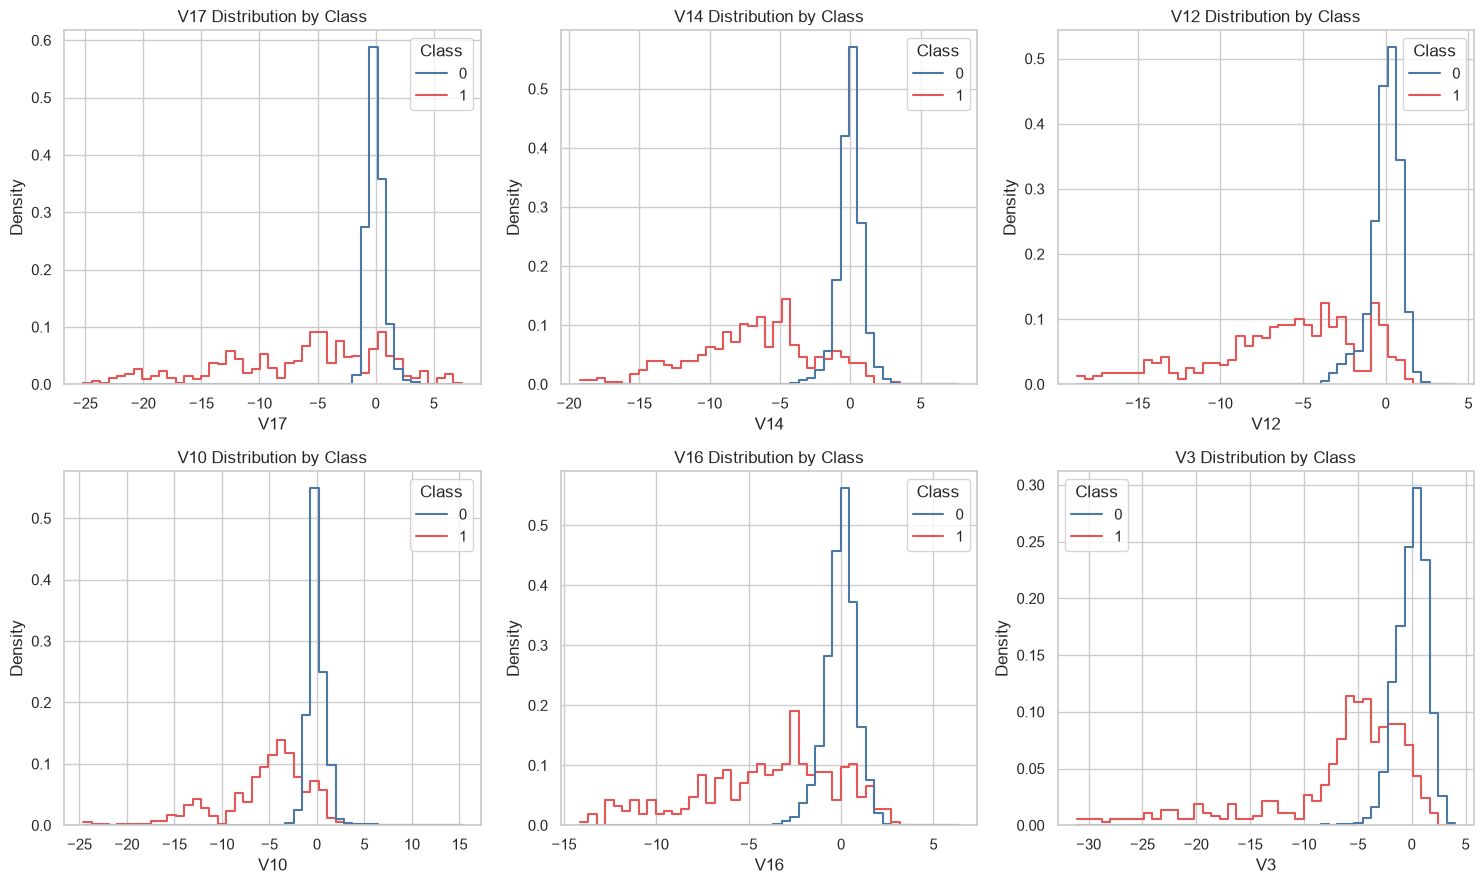

In [13]:
# Sample only the majority class for readability and retain every fraud record.
legitimate_for_distributions = eda_df.loc[eda_df["Class"] == 0].sample(
    n=min(20_000, int((eda_df["Class"] == 0).sum())),
    random_state=RANDOM_STATE,
)
fraud_for_distributions = eda_df.loc[eda_df["Class"] == 1]
distribution_sample = pd.concat(
    [legitimate_for_distributions, fraud_for_distributions],
    ignore_index=True,
)

figure, axes = plt.subplots(2, 3, figsize=(15, 9))
for feature, axis in zip(selected_pca_features, axes.flat):
    sns.histplot(
        data=distribution_sample,
        x=feature,
        hue="Class",
        bins=45,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        palette=["#4C78A8", "#E45756"],
        ax=axis,
    )
    axis.set_title(f"{feature} Distribution by Class")
    axis.set_xlabel(feature)
    axis.set_ylabel("Density")
save_figure("images/deliverable_1/05_selected_feature_distributions.png")
plt.show()

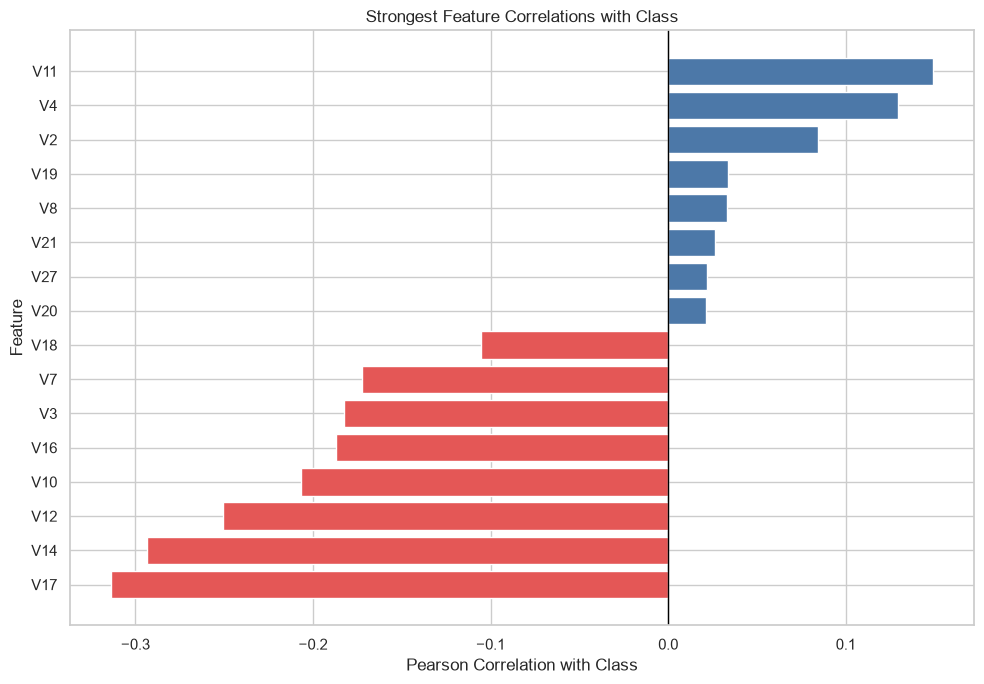

Strongest negative correlation: V17 (-0.3135)
Strongest positive correlation: V11 (0.1491)


In [14]:
# Show focused target correlations without interpreting association as causation.
class_correlations = eda_df[PCA_COLUMNS + ["Time", "Amount", "Hour", "DayIndex", "LogAmount", "Class"]].corr()["Class"].drop("Class")
correlation_display = pd.concat([
    class_correlations.nsmallest(8),
    class_correlations.nlargest(8),
]).drop_duplicates().sort_values()

plt.figure(figsize=(10, 7))
colors = ["#E45756" if value < 0 else "#4C78A8" for value in correlation_display.values]
plt.barh(correlation_display.index, correlation_display.values, color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Strongest Feature Correlations with Class")
plt.xlabel("Pearson Correlation with Class")
plt.ylabel("Feature")
save_figure("images/deliverable_1/06_class_correlations.png")
plt.show()

strongest_negative = class_correlations.idxmin()
strongest_positive = class_correlations.idxmax()
print(
    f"Strongest negative correlation: {strongest_negative} "
    f"({class_correlations.loc[strongest_negative]:.4f})"
)
print(
    f"Strongest positive correlation: {strongest_positive} "
    f"({class_correlations.loc[strongest_positive]:.4f})"
)

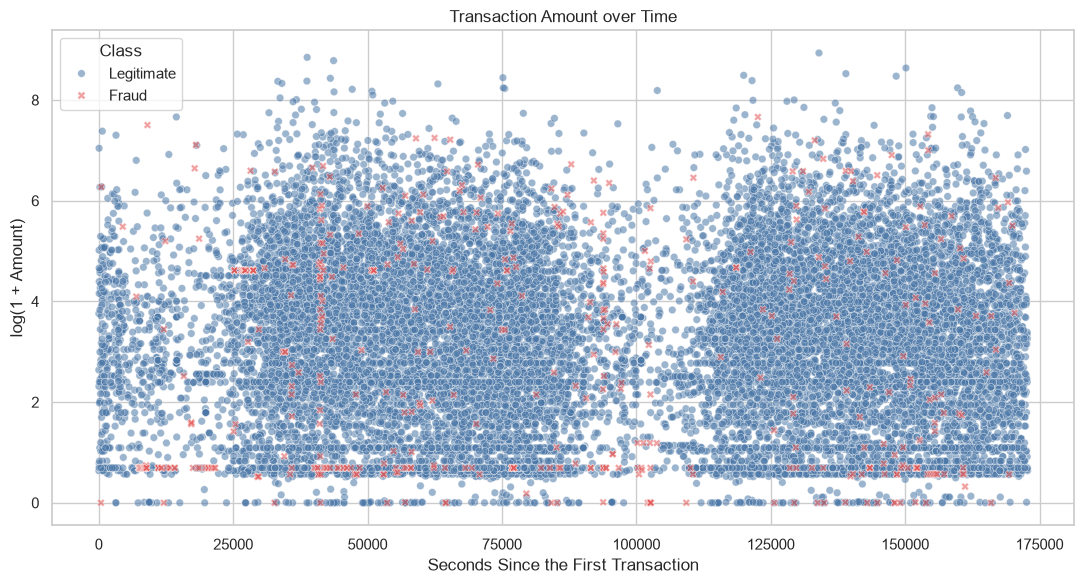

In [15]:
# Use the same fixed seed so the dense scatter sample is reproducible.
legitimate_for_scatter = eda_df.loc[eda_df["Class"] == 0].sample(
    n=min(20_000, int((eda_df["Class"] == 0).sum())),
    random_state=RANDOM_STATE,
)
scatter_sample = pd.concat(
    [legitimate_for_scatter, eda_df.loc[eda_df["Class"] == 1]],
    ignore_index=True,
)

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=scatter_sample,
    x="Time",
    y="LogAmount",
    hue="Class",
    style="Class",
    palette={0: "#4C78A8", 1: "#E45756"},
    alpha=0.55,
    s=30,
)
plt.title("Transaction Amount over Time")
plt.xlabel("Seconds Since the First Transaction")
plt.ylabel("log(1 + Amount)")
legend_handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(legend_handles, ["Legitimate", "Fraud"], title="Class")
save_figure("images/deliverable_1/07_amount_vs_time.png")
plt.show()

### Visualization Interpretation

- The raw transaction amount requires a logarithmic view because a small number of large values compress the majority of observations.
- Comparing `LogAmount` by class tests whether amount behavior differs without claiming that amount alone identifies fraud.
- Hourly transaction volume and observed fraud rate may reveal timing variation, but the historical pattern does not establish causation or guarantee future behavior.
- The six PCA panels are selected using absolute class correlation rather than plotting 28 unreadable panels. Correlation identifies linear association, not causation.
- The amount-versus-time plot uses a reproducible sample of legitimate records and all fraud records for readability; it is exploratory and does not represent balanced population prevalence.

## How EDA Guides Future Modeling

1. **Preserve class proportions:** Classification train/test splits and cross-validation must be stratified because fraud is rare.
2. **Use imbalance-aware metrics:** Accuracy is insufficient. Precision, recall, F1, ROC-AUC, and PR-AUC are required, with special attention to fraud recall and false negatives.
3. **Transform and scale thoughtfully:** `Amount` is strongly right-skewed, and `Time`, `Amount`, and PCA features operate on different numerical scales. Transformations and scaling must be learned inside training pipelines after splitting to prevent leakage.
4. **Retain anomalous records:** Fraud may appear as extreme behavior, so fraud rows and statistical extremes should not be removed automatically as outliers.
5. **Use class-weighted models:** Class weighting is appropriate for the severe imbalance and avoids generating synthetic records before the data split.
6. **Preserve full precision:** Calculations, filtering, model comparison, and thresholds will use raw values; rounding is presentation-only.
7. **Limit causal and domain claims:** PCA features can be statistically useful, but anonymization prevents direct interpretation of the original cardholder or merchant attributes.

These decisions establish a reproducible foundation for regression in Deliverable 2 and classification, clustering, and pattern mining in Deliverable 3.

## 10. Deliverable 1 Artifact Validation

**Objective:** Confirm that the required figures and result tables were generated by this execution. Missing artifacts raise an error rather than allowing an incomplete checkpoint.

In [16]:
# Fail the checkpoint when any required saved result is missing or empty.
required_artifacts = [
    Path("results/deliverable_1_dataset_profile.csv"),
    Path("results/deliverable_1_cleaning_summary.csv"),
    *[
        Path("images/deliverable_1") / filename
        for filename in [
            "01_class_distribution.png",
            "02_amount_distribution.png",
            "03_log_amount_by_class.png",
            "04_transactions_by_hour.png",
            "05_selected_feature_distributions.png",
            "06_class_correlations.png",
            "07_amount_vs_time.png",
        ]
    ],
]
artifact_status = pd.DataFrame({
    "Artifact": [str(path) for path in required_artifacts],
    "Exists": [path.is_file() for path in required_artifacts],
    "Size Bytes": [path.stat().st_size if path.is_file() else 0 for path in required_artifacts],
})
display(artifact_status)
if not artifact_status["Exists"].all() or (artifact_status["Size Bytes"] <= 0).any():
    raise FileNotFoundError("One or more required Deliverable 1 artifacts are missing or empty.")

,Artifact,Exists,Size Bytes
0,results/deliverable_1_dataset_profile.csv,True,240
1,results/deliverable_1_cleaning_summary.csv,True,270
2,images/deliverable_1/01_class_distribution.png,True,38815
3,images/deliverable_1/02_amount_distribution.png,True,45694
4,images/deliverable_1/03_log_amount_by_class.png,True,37812
5,images/deliverable_1/04_transactions_by_hour.png,True,126937
6,images/deliverable_1/05_selected_feature_distr...,True,150826
7,images/deliverable_1/06_class_correlations.png,True,56935
8,images/deliverable_1/07_amount_vs_time.png,True,1708075


## Deliverable 1 Conclusions

This deliverable creates an auditable data-preparation and EDA workflow for the approved credit-card fraud dataset. It verifies schema and missingness, removes only exact duplicates, measures class impact, retains plausible statistical extremes, quantifies target imbalance, adds non-destructive exploratory features, and saves focused visual evidence.

The primary challenge is that fraud is extremely rare and the PCA features are anonymized. The project addresses these constraints by avoiding accuracy-only conclusions, preserving possible anomaly signals, using reproducible samples only for dense visualizations, and planning leakage-safe, class-aware evaluation for later deliverables.